In [3]:
# --- STEP 1: Imports and data load ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv("../data/synthetic_ev_data.csv", parse_dates=["timestamp"])
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10000, 18)


,timestamp,hour,day_of_week,avg_speed_kmph,trip_distance_km,elevation_gain_m,traffic_index,ambient_temp_c,rain_flag,battery_age_years,tyre_pressure_psi,hvac_on,payload_kg,soc_start,soh,energy_wh_per_km,usable_kwh,predicted_range_km
0,2024-01-01 00:00:00,0,0,52.450712,6.572042,63.931450,0.103886,21.696997,0,2.286192,37.963816,0,84.780039,85.359524,0.898718,134.398197,53.923086,342.478477
1,2024-01-01 00:05:00,0,0,42.926035,9.556004,61.332944,0.289003,32.088917,0,1.792875,36.508119,1,136.045125,93.624599,0.921966,156.226224,55.317936,331.514099
2,2024-01-01 00:10:00,0,0,54.715328,7.220952,12.539206,0.382594,23.612692,1,1.527735,37.839879,0,160.368942,73.591481,0.947913,129.263340,56.874760,323.796196
3,2024-01-01 00:15:00,0,0,67.845448,12.883344,73.183369,0.529934,25.633985,1,3.931793,33.502745,0,166.737282,71.515964,0.800791,158.517840,48.047467,216.768088
4,2024-01-01 00:20:00,0,0,41.487699,21.577428,0.000000,0.704832,30.021734,0,0.570534,35.746680,1,214.524474,91.892013,0.998241,161.910135,59.894464,339.930721


In [4]:
#Step 2 — Basic summary & sanity check
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           10000 non-null  datetime64[ns]
 1   hour                10000 non-null  int64         
 2   day_of_week         10000 non-null  int64         
 3   avg_speed_kmph      10000 non-null  float64       
 4   trip_distance_km    10000 non-null  float64       
 5   elevation_gain_m    10000 non-null  float64       
 6   traffic_index       10000 non-null  float64       
 7   ambient_temp_c      10000 non-null  float64       
 8   rain_flag           10000 non-null  int64         
 9   battery_age_years   10000 non-null  float64       
 10  tyre_pressure_psi   10000 non-null  float64       
 11  hvac_on             10000 non-null  int64         
 12  payload_kg          10000 non-null  float64       
 13  soc_start           10000 non-null  float64    

,count,mean,min,25%,50%,75%,max,std
timestamp,10000,2024-01-18 08:37:30,2024-01-01 00:00:00,2024-01-09 16:18:45,2024-01-18 08:37:30,2024-01-27 00:56:15,2024-02-04 17:15:00,NaN
hour,10000.0,11.4308,0.0,5.0,11.0,17.0,23.0,6.904461
day_of_week,10000.0,2.976,0.0,1.0,3.0,5.0,6.0,1.98993
avg_speed_kmph,10000.0,44.988335,5.0,34.911142,44.961075,55.066213,103.893566,14.991721
trip_distance_km,10000.0,12.414828,1.0,6.703913,12.126774,17.550919,47.832674,7.42385
elevation_gain_m,10000.0,51.445327,0.0,21.993923,49.76927,76.555897,197.66498,36.241009
traffic_index,10000.0,0.498592,0.0,0.361077,0.497924,0.635806,1.0,0.19845
ambient_temp_c,10000.0,25.010626,-5.0,20.351526,25.066925,29.786845,40.0,6.916996
rain_flag,10000.0,0.1995,0.0,0.0,0.0,0.0,1.0,0.399644
battery_age_years,10000.0,2.083722,0.0,1.001644,2.032689,3.035702,7.24267,1.387441


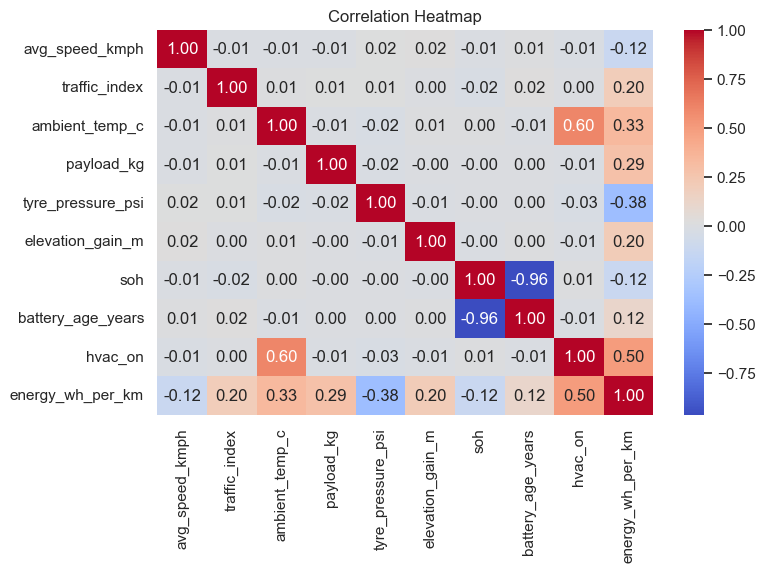

In [5]:
#Step 3 — Correlation heatmap
num_cols = ['avg_speed_kmph','traffic_index','ambient_temp_c','payload_kg',
            'tyre_pressure_psi','elevation_gain_m','soh','battery_age_years',
            'hvac_on','energy_wh_per_km']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

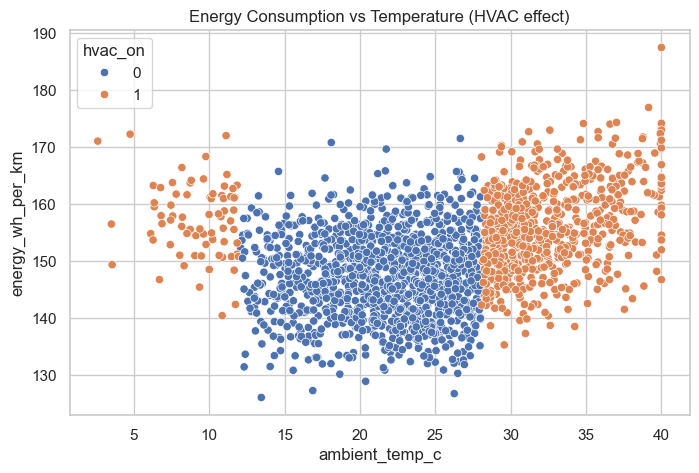

In [6]:
#Step 4 — Energy vs Temperature and HVAC
sns.scatterplot(x="ambient_temp_c", y="energy_wh_per_km",
                hue="hvac_on", data=df.sample(2000))
plt.title("Energy Consumption vs Temperature (HVAC effect)")
plt.show()

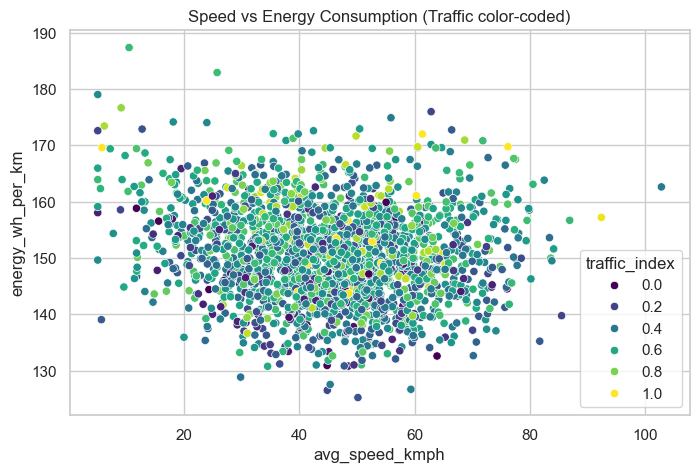

In [7]:
#Step 5 — Traffic & Speed Influence
sns.scatterplot(x="avg_speed_kmph", y="energy_wh_per_km",
                hue="traffic_index", palette="viridis",
                data=df.sample(2000))
plt.title("Speed vs Energy Consumption (Traffic color-coded)")
plt.show()


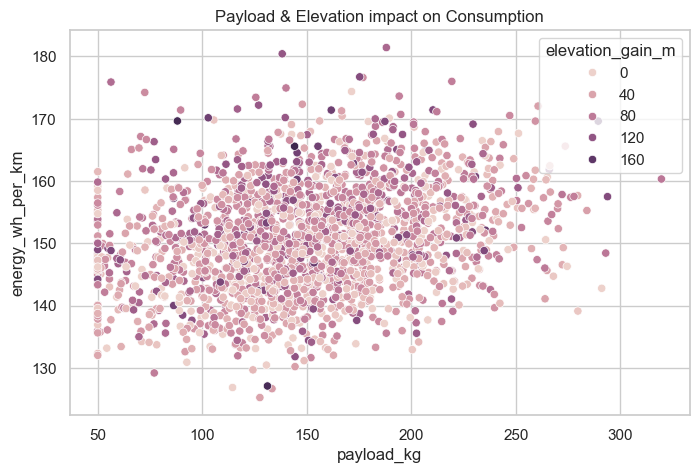

In [8]:
#Step 6 — Elevation & Payload Effects
sns.scatterplot(x="payload_kg", y="energy_wh_per_km",
                hue="elevation_gain_m", data=df.sample(2000))
plt.title("Payload & Elevation impact on Consumption")
plt.show()

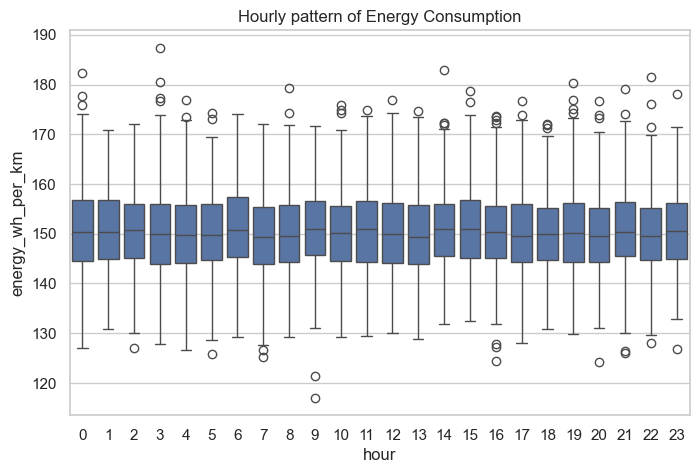

In [9]:
#Step 7 — Hour-of-day pattern
df['hour'] = df['timestamp'].dt.hour
sns.boxplot(x="hour", y="energy_wh_per_km", data=df)
plt.title("Hourly pattern of Energy Consumption")
plt.show()

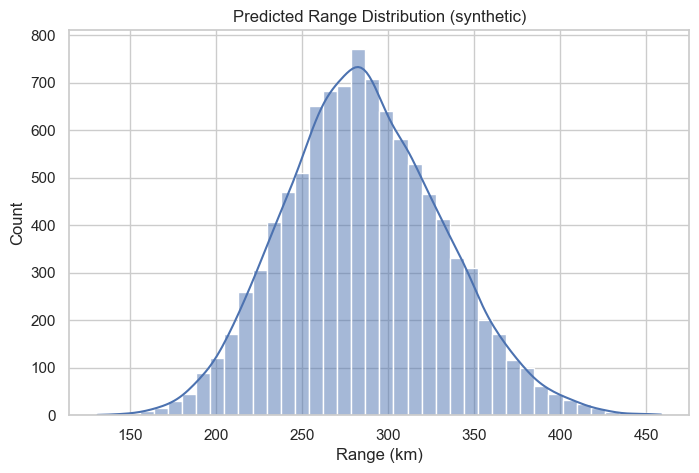

In [10]:
#Step 8 — Range distribution
sns.histplot(df['predicted_range_km'], bins=40, kde=True)
plt.title("Predicted Range Distribution (synthetic)")
plt.xlabel("Range (km)")
plt.show()

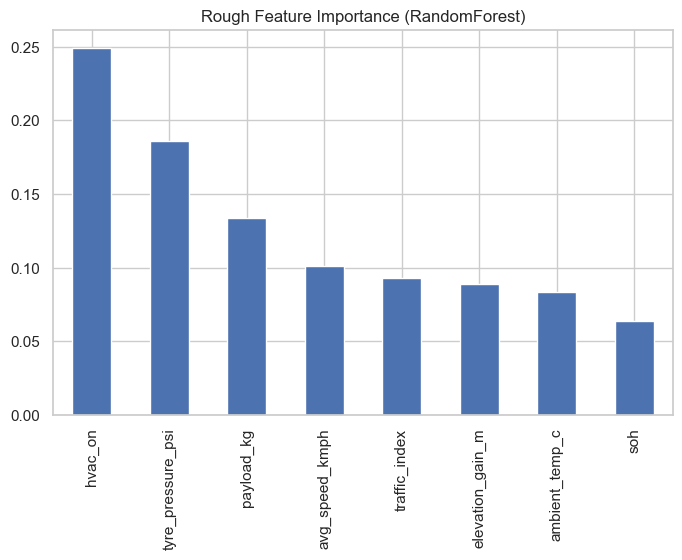

In [11]:
#Step 9 — Feature importance (quick proxy)
from sklearn.ensemble import RandomForestRegressor

X = df[['avg_speed_kmph','traffic_index','ambient_temp_c','payload_kg',
        'tyre_pressure_psi','elevation_gain_m','soh','hvac_on']]
y = df['energy_wh_per_km']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar')
plt.title("Rough Feature Importance (RandomForest)")
plt.show()

In [ ]:
from src.data_pipeline import load_data, feature_engineering, split_and_scale

df = load_data()
X, y, df_all = feature_engineering(df)
X_train, X_val, y_train, y_val, scaler = split_and_scale(X, y)

print(X_train.head())
